<h4 style="font-size: 30px;"><strong>Fig2: Annual temporal scale considering the ENSO</strong></h4>
<h4 style="font-size: 20px;"><strong>ENSO</strong></h4>


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FixedLocator
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
from glob import glob
import calendar

hourly_input = '../DATA/rainfall/hourly_gauges_SIATA_EPM/'
daily_output = '../DATA/rainfall/daily_gauges_SIATA_EPM/'
monthly_output = '../DATA/rainfall/monthly_gauges_SIATA_EPM/'
annual_output = '../DATA/rainfall/annual_gauges_SIATA_EPM/'
path_ENSO = '../DATA/rainfall/ENSO/'
path_inventory = '../DATA/landslides/'
output_figures = '../FIGURES/temporal_analysis/'


enso_df = pd.read_excel(f'{path_ENSO}ONI.xlsx', index_col=0)

enso_df.columns = np.arange(1, 13)
enso_series = enso_df.stack().reset_index()
enso_series.columns = ['Year', 'Month', 'ENSO']
enso_series['Date'] = pd.to_datetime(enso_series[['Year', 'Month']].assign(day=1))

start_date = "1950-01-01"
end_date = "2024-01-01"
enso_series = enso_series[(enso_series['Date'] >= start_date) & (enso_series['Date'] < end_date)]

month_mapping = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

enso_series['Month'] = enso_series['Month'].map(month_mapping)

enso_series['ENSO_Category'] = pd.cut(
    enso_series['ENSO'], 
    bins=[-np.inf, -2, -1.5, -1, -0.5, 0.5, 1, 1.5, 2, np.inf], 
    labels=['La Niña-Super', 'La Niña-Strong', 'La Niña-Moderate', 'La Niña-Weak', 'Neutral', 
            'El Niño-Weak', 'El Niño-Strong', 'El Niño-Moderate', 'El Niño-Super']
)

cmap_dict = {
    'La Niña-Super': '#001F3F', 'La Niña-Strong': '#0074D9', 'La Niña-Moderate': '#3BADC9', 'La Niña-Weak': '#7FDBFF',
    'Neutral': '#E0E0E0', 'El Niño-Weak': '#FF9999', 'El Niño-Strong': '#FF6666', 'El Niño-Moderate': '#FF4D4D', 
    'El Niño-Super': '#800020'
}
cmap_class = ListedColormap([cmap_dict[i] for i in cmap_dict])

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
enso_series['Month'] = pd.Categorical(enso_series['Month'], categories=month_order, ordered=True)

<h4 style="font-size: 20px;"><strong>Landslides</strong></h4>

In [ ]:
month_mapping = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

landslides_df = pd.read_csv(f'{path_inventory}inventory_GEOHAZARDS_20240824.csv')
landslides_df['Fecha'] = pd.to_datetime(landslides_df['Fecha'], errors='coerce')

landslides_df = landslides_df[(landslides_df['Fecha'] >= '1950-01-01') & (landslides_df['Fecha'] <= '2024-01-01')]

landslides_series = landslides_df.resample('M', on='Fecha').size()

landslides_series = landslides_series.reset_index()
landslides_series['Year'] = landslides_series['Fecha'].dt.year
landslides_series['Month'] = landslides_series['Fecha'].dt.month.map(month_mapping)

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
landslides_series['Month'] = pd.Categorical(landslides_series['Month'], categories=month_order, ordered=True)

landslides_pivot = landslides_series.pivot_table(index='Month', columns='Year', values=0, aggfunc='sum').fillna(0).astype(int)

<h4 style="font-size: 20px;"><strong>Rainfall</strong></h4>


In [ ]:
monthly_files = sorted(glob(monthly_output + 'Monthly_Est_*.csv'))
stations_with_paths = [(int(file.split('_')[-1].split('.')[0]), file) for file in monthly_files]

stations_with_paths_sorted = sorted(stations_with_paths, key=lambda x: x[0])

monthly_files = [station[1] for station in stations_with_paths_sorted]

all_stations_df = pd.DataFrame()

for file in monthly_files:
    station_data = pd.read_csv(file, index_col='Fecha', parse_dates=True)
    all_stations_df = pd.concat([all_stations_df, station_data], axis=1)

all_stations_df = all_stations_df[(all_stations_df.index >= '1950-01-01') & (all_stations_df.index <= '2023-12-31')]

rainfall_series = all_stations_df.mean(axis=1).resample('M').sum()

In [ ]:
month_mapping = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
monthly_rainfall_sum = rainfall_series.groupby(rainfall_series.index.month).mean()

monthly_rainfall_sum.index = monthly_rainfall_sum.index.map(month_mapping)
monthly_rainfall_sum = monthly_rainfall_sum.reindex(month_order)


<h4 style="font-size: 20px;"><strong>Matrix</strong></h4>

In [ ]:
enso_matrix = enso_series.pivot_table(index='Month', columns='Year', values='ENSO_Category', aggfunc='first').reindex(index=month_order)
df_class = pd.DataFrame({
    'year': np.repeat(enso_matrix.columns, enso_matrix.index.size),
    'month': np.tile(enso_matrix.index, enso_matrix.columns.size),
    'E': enso_matrix.values.ravel(),
    'anot': np.zeros(enso_matrix.values.ravel().shape)  
})

y = enso_matrix.columns.size
m = enso_matrix.index.size
data_P = enso_matrix.applymap(lambda x: list(cmap_dict.keys()).index(x) if pd.notna(x) else np.nan).values

landslides_pivot = landslides_series.pivot_table(index='Month', columns='Year', values=0, aggfunc='sum').reindex(index=month_order)
landslides_matrix = landslides_pivot.reindex(index=enso_matrix.index, columns=enso_matrix.columns).fillna(0).astype(int)
annot_labels = landslides_matrix.applymap(str).replace('0', '') 
data_M = annot_labels.values

<h4 style="font-size: 20px;"><strong>ENSO with more events</strong></h4>

In [ ]:
landslides_filtered = landslides_matrix[landslides_matrix > 15].stack().reset_index()
landslides_filtered.columns = ['Month', 'Year', 'Landslides']

enso_filtered = enso_series[['Year', 'Month', 'ENSO_Category']]
enso_filtered = enso_filtered.rename(columns={'ENSO_Category': 'ENSO_Type'})

events_enso = landslides_filtered.merge(enso_filtered, on=['Year', 'Month'], how='left')

events_enso = events_enso.sort_values(by='Year')

events_enso

,Month,Year,Landslides,ENSO_Type
2,May,1981,19.0,Neutral
3,May,1982,17.0,El Niño-Weak
18,Oct,1986,18.0,El Niño-Weak
4,May,1987,20.0,El Niño-Weak
23,Nov,1988,21.0,La Niña-Strong
16,Aug,1995,16.0,La Niña-Weak
5,May,1996,20.0,Neutral
6,May,1998,27.0,Neutral
0,Mar,1999,18.0,La Niña-Moderate
24,Nov,1999,20.0,La Niña-Strong


<h4 style="font-size: 20px;"><strong>Graphic</strong></h4>

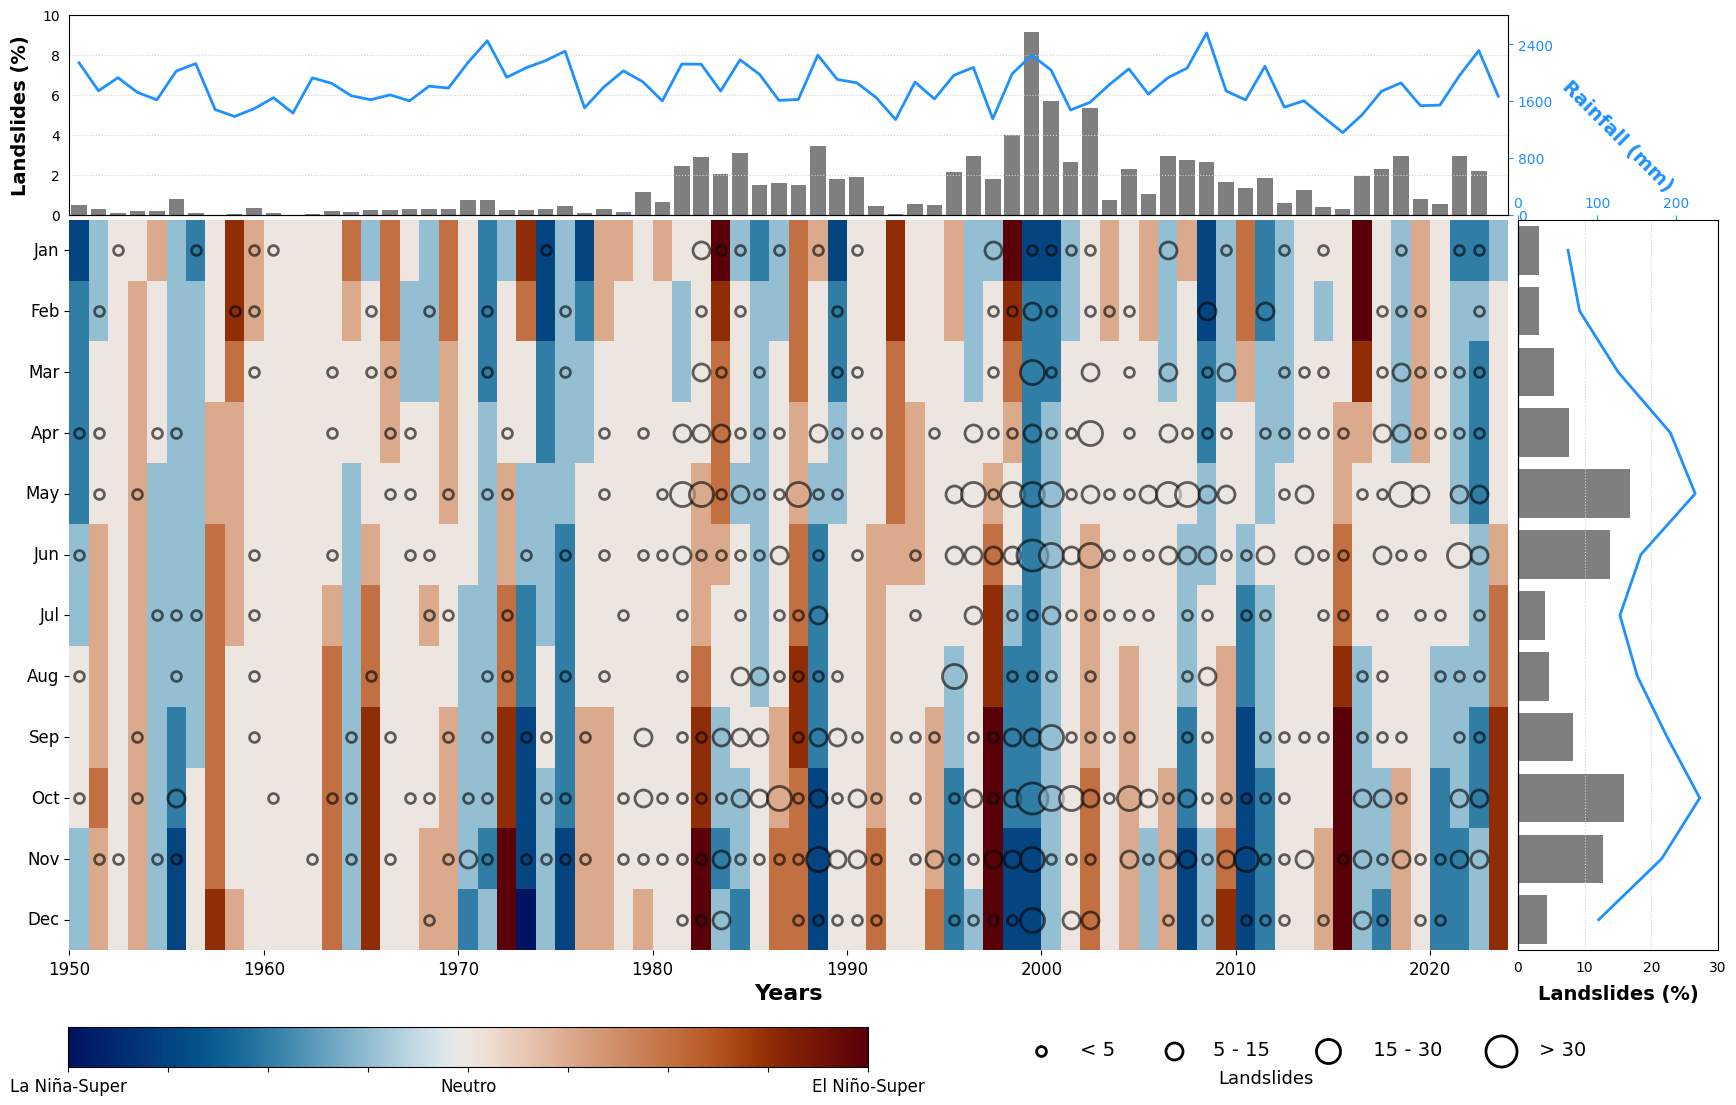

In [ ]:
import cmcrameri.cm as cm  # << aquí usas cmcrameri
from matplotlib.transforms import Bbox

g = sns.jointplot(data=df_class, x='year', y='month', kind='hist', bins=(y, m), cmap='YlOrRd')
g.ax_marg_y.cla()
g.ax_marg_x.cla()

#sns.heatmap(data=data_P, ax=g.ax_joint, cbar=False, cmap='coolwarm') 
sns.heatmap(data=data_P, ax=g.ax_joint, cbar=False, cmap=cm.vik) 

data_M = np.array(data_M, dtype=object)
data_M = np.where(data_M == '', '0', data_M)

data_M = data_M.astype(int)

norm = mcolors.Normalize(vmin=np.min(data_P), vmax=np.max(data_P))
cmap = cm.vik

def get_circle_size(value):
    if value == 0:
        return 0  # Sin círculo
    elif 1 <= value <= 5:
        return 50  # Círculo pequeño
    elif 6 <= value <= 15:
        return 150  # Círculo mediano
    elif 16 <= value <= 30:
        return 300  # Círculo grande
    else:
        return 500  # Círculo muy grande

scaled_sizes = np.array([[get_circle_size(val) for val in row] for row in data_M])

for (i, j), val in np.ndenumerate(data_M):
    if val > 0:
        color = cmap(norm(data_P[i, j]))
        g.ax_joint.scatter(j + 0.5, i + 0.5, s=scaled_sizes[i, j], color=color, alpha=0.6, edgecolor='black',lw=2)

legend_labels = ['< 5', '5 - 15', ' 15 - 30', '> 30']
legend_sizes = [50, 150, 300, 500]

legend_circles = [plt.scatter([], [], s=size, color='white', edgecolor='black', linewidth=2) for size in legend_sizes]
g.ax_joint.legend(legend_circles, legend_labels, loc='upper left', bbox_to_anchor=(0.65, -0.10), 
                  handletextpad=1, labelspacing=1.2, ncol=4, fontsize=14, frameon=False)

total_landslides = landslides_matrix.sum().sum()

df_y_pct = (landslides_matrix.sum(axis=0) / total_landslides) * 100  # Porcentaje por año
df_m_pct = (landslides_matrix.sum(axis=1) / total_landslides) * 100  # Porcentaje por mes

#df_y = landslides_matrix.sum(axis=0)
#df_m = landslides_matrix.sum(axis=1)

g.ax_marg_y.barh(np.arange(0.5, m), 
                 df_m_pct,
                 color='black', 
                 alpha=0.5)

g.ax_marg_x.bar(np.arange(0.5, y), 
                df_y_pct,
                color='black', 
                alpha=0.5)

ax2 = g.ax_marg_x.twinx()
P_y = rainfall_series.groupby(rainfall_series.index.year).sum().reindex(enso_matrix.columns, fill_value=0)
ax2.tick_params(axis='y', colors='dodgerblue')
ax2.plot(np.arange(0.5, y), P_y, color='dodgerblue', linewidth=2, linestyle='-')

ax2.set_ylim(0, P_y.max() * 1.1)

ax2.yaxis.set_major_locator(MaxNLocator(nbins=4))

ax2y = g.ax_marg_y.twiny()
P_m = monthly_rainfall_sum.reindex(enso_matrix.index, fill_value=0)
ax2y.plot(P_m, np.arange(0.5, m), color='dodgerblue', linewidth=2, linestyle='-')
ax2y.tick_params(axis='x', colors='dodgerblue')
ax2y.set_xlabel('Rainfall (mm)', fontsize=14, color='dodgerblue', fontweight='bold', rotation=-45)
ax2y.set_xlim(0, P_m.max() * 1.1)

g.ax_joint.set_xticks(np.arange(0, y, 10))
g.ax_joint.set_xticklabels(np.arange(enso_matrix.columns[0], enso_matrix.columns[-1], 10), rotation=0, fontsize=12)
g.ax_joint.set_yticks(np.arange(0.5, m))
g.ax_joint.set_yticklabels(enso_matrix.index, rotation=0, fontsize=12)
g.ax_joint.set_xlabel('Years', fontsize=16, fontweight='bold')

g.ax_marg_x.tick_params(axis='x', bottom=False, labelbottom=False)
g.ax_marg_y.tick_params(axis='y', left=False, labelleft=False)
g.ax_marg_x.tick_params(axis='y', left=False, labelleft=False)
g.ax_marg_y.tick_params(axis='x', bottom=False, labelbottom=False)

g.fig.set_size_inches(20, 10)
g.fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Crear la barra de color más pequeña
# Ajustar la altura de la barra de color (por ejemplo, 0.02 de altura en lugar de 0.04)
cax = g.fig.add_axes([0.11, -0.02, 0.40, 0.04])  # Cambiar la última coordenada para hacerla más pequeña

cbar = g.fig.colorbar(g.ax_joint.collections[1], cax=cax, orientation='horizontal')

n_classes = 9
cbar.ax.xaxis.set_major_locator(FixedLocator([i for i in range(n_classes)]))

cbar.ax.set_xticklabels(['La Niña-Super', ' ', ' ', ' ', 'Neutro',' ', ' ', ' ', 'El Niño-Super'], fontsize=12, rotation=0, color='black')

g.ax_marg_y.grid(True, axis='x', ls=':', color='lightgray')
g.ax_marg_x.grid(True, axis='y', ls=':', color='lightgray')

g.ax_marg_y.tick_params(labelbottom=True)
g.ax_marg_y.grid(True, axis='x', ls=':')
g.ax_marg_y.set_xlim(0,30)

g.ax_marg_x.tick_params(labelleft=True)
g.ax_marg_x.grid(True, axis='y', ls=':')
g.ax_marg_x.set_ylim(0,10)

font_dict = ax2y.xaxis.label.get_font_properties().copy()
g.ax_marg_y.text(3, 12.8, 'Landslides (%)', fontproperties=font_dict) # Right bar plot
g.ax_marg_x.text(-3, 1.2, 'Landslides (%)', fontproperties=font_dict, rotation=90) # Upper bar plot


ax_joint  = g.ax_joint     # heat-map central
ax_top    = g.ax_marg_x    # barras anuales  (superior)
ax_right  = g.ax_marg_y    # barras mensuales (derecha)

pos_joint = ax_joint.get_position()

width_r   = 0.10
gap_r     = 0.005

new_right = Bbox.from_extents(
    pos_joint.x1 + gap_r,
    pos_joint.y0,
    pos_joint.x1 + gap_r + width_r,
    pos_joint.y1
)
ax_right.set_position(new_right)

height_t  = 0.20
gap_t     = gap_r

new_top = Bbox.from_extents(
    pos_joint.x0,                  # x0 alinear con joint
    pos_joint.y1 + gap_t,          # y0 nuevo = borde superior del joint + gap
    pos_joint.x1,                  # x1 alinear con joint
    pos_joint.y1 + gap_t + height_t# y1 nuevo
)
ax_top.set_position(new_top)

ax_top.set_ylim(0, 10)
ax_right.set_xlim(0, 30)


plt.text(11.5,-0.4, 'Landslides', fontsize = 13)
plt.show()
#g.fig.savefig(f'{output_figures}fig02.png', bbox_inches = "tight", dpi=300)